In [73]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [74]:
df_original = pd.read_csv('NY-House-Dataset.csv')

In [75]:
# Data Cleaning
# Initial Inspection
df_original.head()

,BROKERTITLE,TYPE,PRICE,BEDS,BATH,PROPERTYSQFT,ADDRESS,STATE,MAIN_ADDRESS,ADMINISTRATIVE_AREA_LEVEL_2,LOCALITY,SUBLOCALITY,STREET_NAME,LONG_NAME,FORMATTED_ADDRESS,LATITUDE,LONGITUDE
0,Brokered by Douglas Elliman -111 Fifth Ave,Condo for sale,315000,2,2.00,1400.00,2 E 55th St Unit 803,"New York, NY 10022","2 E 55th St Unit 803New York, NY 10022",New York County,New York,Manhattan,East 55th Street,Regis Residence,"Regis Residence, 2 E 55th St #803, New York, N...",40.76,-73.97
1,Brokered by Serhant,Condo for sale,195000000,7,10.00,17545.00,Central Park Tower Penthouse-217 W 57th New Yo...,"New York, NY 10019",Central Park Tower Penthouse-217 W 57th New Yo...,United States,New York,New York County,New York,West 57th Street,"217 W 57th St, New York, NY 10019, USA",40.77,-73.98
2,Brokered by Sowae Corp,House for sale,260000,4,2.00,2015.00,620 Sinclair Ave,"Staten Island, NY 10312","620 Sinclair AveStaten Island, NY 10312",United States,New York,Richmond County,Staten Island,Sinclair Avenue,"620 Sinclair Ave, Staten Island, NY 10312, USA",40.54,-74.20
3,Brokered by COMPASS,Condo for sale,69000,3,1.00,445.00,2 E 55th St Unit 908W33,"Manhattan, NY 10022","2 E 55th St Unit 908W33Manhattan, NY 10022",United States,New York,New York County,New York,East 55th Street,"2 E 55th St, New York, NY 10022, USA",40.76,-73.97
4,Brokered by Sotheby's International Realty - E...,Townhouse for sale,55000000,7,2.37,14175.00,5 E 64th St,"New York, NY 10065","5 E 64th StNew York, NY 10065",United States,New York,New York County,New York,East 64th Street,"5 E 64th St, New York, NY 10065, USA",40.77,-73.97


In [76]:
# Check for missing values
missing_values = df_original.isnull().sum()
print(missing_values)

BROKERTITLE                    0
TYPE                           0
PRICE                          0
BEDS                           0
BATH                           0
PROPERTYSQFT                   0
ADDRESS                        0
STATE                          0
MAIN_ADDRESS                   0
ADMINISTRATIVE_AREA_LEVEL_2    0
LOCALITY                       0
SUBLOCALITY                    0
STREET_NAME                    0
LONG_NAME                      0
FORMATTED_ADDRESS              0
LATITUDE                       0
LONGITUDE                      0
dtype: int64


In [77]:
# Check for duplicates
duplicates = df_original.duplicated().sum()
print('Number of duplicate rows: ', duplicates)

Number of duplicate rows:  214


In [78]:
# Drop rows with missing values in important columns 
df_cleaned = df_original.copy()
df_cleaned.dropna(subset = ['PRICE', 'BEDS', 'BATH', 'PROPERTYSQFT', 'TYPE', 'LOCALITY'], inplace=True)
df_cleaned.drop_duplicates(inplace=True)
duplicates_cleaned=df_cleaned.duplicated().sum()
print('Number of duplicate rows after cleaning: ', duplicates_cleaned)

Number of duplicate rows after cleaning:  0


In [79]:
# Convert data types
df_cleaned['PRICE'] = pd.to_numeric(df_cleaned['PRICE'], errors='coerce')
df_cleaned['BEDS'] = pd.to_numeric(df_cleaned['BEDS'], errors='coerce')
df_cleaned['BATH'] = pd.to_numeric(df_cleaned['BATH'], errors='coerce')
df_cleaned['PROPERTYSQFT'] = pd.to_numeric(df_cleaned['PROPERTYSQFT'], errors='coerce')

In [80]:
# Filter out invalid of zero values in critical columns
df_cleaned = df_cleaned[(df_cleaned['PRICE'] > 0) & (df_cleaned['PROPERTYSQFT'] > 0)]

In [81]:
# Remove outliers
price_threshold = df_cleaned['PRICE'].quantile(0.99)
size_threshold = df_cleaned['PROPERTYSQFT'].quantile(0.99)
df_cleaned = df_cleaned[(df_cleaned['PRICE'] <= price_threshold) & (df_cleaned['PROPERTYSQFT'] <= size_threshold)]

In [82]:
# Add a PRICE_PER_SQFT column
df_cleaned['PRICE_PER_SQFT'] = df_cleaned['PRICE']/df_cleaned['PROPERTYSQFT']

In [83]:
# Standardize geographic data
df_cleaned['LOCALITY'] = df_cleaned['LOCALITY'].str.strip().str.title()
df_cleaned['ADMINISTRATIVE_AREA_LEVEL_2'] = df_cleaned['ADMINISTRATIVE_AREA_LEVEL_2'].str.strip().str.title()

In [84]:
df_cleaned['PRICE'] = df_cleaned['PRICE'].round(2)
df_cleaned['PRICE_PER_SQFT'] = df_cleaned['PRICE_PER_SQFT'].round(2)
df_cleaned['BEDS'] = df_cleaned['BEDS'].round(2)
df_cleaned['BATH'] = df_cleaned['BATH'].round(2)
df_cleaned['PROPERTYSQFT'] = df_cleaned['PROPERTYSQFT'].round(2)

In [85]:
# Descriptive Statistics
# Numerical Summary
# Set the display format for floats to show 2 decimal places
pd.set_option('display.float_format', '{:.2f}'.format)
numeric_summary = df_cleaned[['PRICE', 'BEDS', 'BATH', 'PROPERTYSQFT', 'PRICE_PER_SQFT']].describe()
print(numeric_summary)

            PRICE    BEDS    BATH  PROPERTYSQFT  PRICE_PER_SQFT
count     4511.00 4511.00 4511.00       4511.00         4511.00
mean   1532201.48    3.26    2.27       2002.56          715.82
std    2402801.42    2.18    1.43       1143.16          776.98
min       2494.00    1.00    0.00        230.00            1.14
25%     495000.00    2.00    1.00       1200.00          322.91
50%     799999.00    3.00    2.00       2184.21          486.88
75%    1425000.00    4.00    3.00       2184.21          807.19
max   22500000.00   32.00   12.00       9026.00         9614.47


In [86]:
# Average price per square foot
average_price_per_sqft = df_cleaned['PRICE_PER_SQFT'].mean()
print(f'Average price per square foot: ${average_price_per_sqft:,.2f}')

Average price per square foot: $715.82


In [87]:
# Property types
property_type_counts = df_cleaned['TYPE'].value_counts()
print('Property counts by type\n')
print(property_type_counts)

Property counts by type

TYPE
Co-op for sale                1382
House for sale                 953
Condo for sale                 832
Multi-family home for sale     678
Townhouse for sale             263
Pending                        228
Contingent                      87
Land for sale                   47
For sale                        20
Foreclosure                     14
Condop for sale                  4
Coming Soon                      2
Mobile house for sale            1
Name: count, dtype: int64


In [88]:
# Geographic Distribution
locality_distribution = df_cleaned['LOCALITY'].value_counts()
print('Geographic distribution\n')
print(locality_distribution)

Geographic distribution

LOCALITY
New York           2334
New York County     917
Queens County       536
Kings County        440
Bronx County        172
Richmond County      58
United States        37
Brooklyn              6
Queens                6
The Bronx             4
Flatbush              1
Name: count, dtype: int64


In [89]:
# Price Analysis
# Most and least expensive properties
most_expensive = df_cleaned.loc[df_cleaned['PRICE'].idxmax()]
least_expensive = df_cleaned.loc[df_cleaned['PRICE'].idxmin()]
print("\nMost expensive property:")
print(most_expensive)
print("\nLeast expensive property:")
print(least_expensive)


Most expensive property:
BROKERTITLE                    Brokered by Douglas Elliman - 575 Madison Ave
TYPE                                                      Townhouse for sale
PRICE                                                               22500000
BEDS                                                                       5
BATH                                                                    6.00
PROPERTYSQFT                                                         8725.00
ADDRESS                                                         10 E 64th St
STATE                                                     New York, NY 10065
MAIN_ADDRESS                                  10 E 64th StNew York, NY 10065
ADMINISTRATIVE_AREA_LEVEL_2                                    United States
LOCALITY                                                            New York
SUBLOCALITY                                                  New York County
STREET_NAME                                       

In [90]:
# Average price by type & locality
price_by_type = df_cleaned.groupby('TYPE')['PRICE'].mean().round(2).sort_values(ascending=False)
price_by_locality = df_cleaned.groupby('LOCALITY')['PRICE'].mean().round(2).sort_values(ascending=False)
print("\nAverage price by type:")
print(price_by_type)
print("\nAverage price by locality:")
print(price_by_locality)


Average price by type:
TYPE
Townhouse for sale           4560895.21
Condo for sale               2074803.94
For sale                     1954535.95
Multi-family home for sale   1449865.66
Foreclosure                  1343010.36
House for sale               1309998.84
Mobile house for sale        1288000.00
Pending                      1210516.86
Coming Soon                  1172000.00
Land for sale                1104854.21
Condop for sale               967000.00
Co-op for sale                929041.65
Contingent                    888693.17
Name: PRICE, dtype: float64

Average price by locality:
LOCALITY
New York County   2128921.40
New York          1799676.47
Brooklyn          1426166.67
United States     1327848.32
Kings County       850264.98
Flatbush           650000.00
Queens             517333.33
Richmond County    449264.40
Queens County      443988.55
Bronx County       338824.95
The Bronx          306000.00
Name: PRICE, dtype: float64


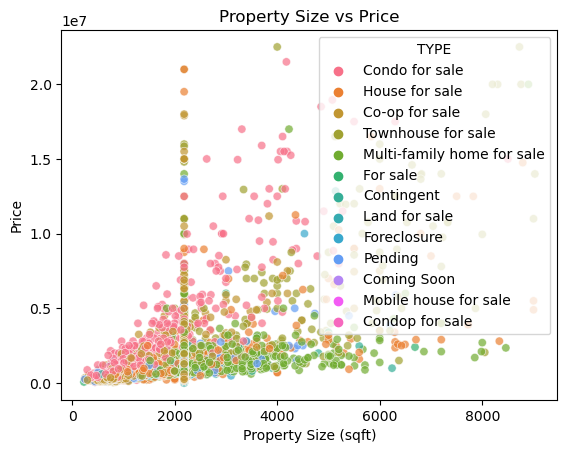

In [91]:
# Size & features
# Relationship between size & price
sns.scatterplot(data = df_cleaned, x='PROPERTYSQFT', y='PRICE', hue='TYPE', alpha=0.7)
plt.title("Property Size vs Price")
plt.xlabel("Property Size (sqft)")
plt.ylabel("Price")
plt.show()

In [92]:
# Correlation between BEDS, BATH & PRICE
correlation_matrix = df_cleaned[['BEDS', 'BATH', 'PRICE']].corr()
print("\nCorrelation between features:")
print(correlation_matrix)


Correlation between features:
       BEDS  BATH  PRICE
BEDS   1.00  0.74   0.26
BATH   0.74  1.00   0.46
PRICE  0.26  0.46   1.00


In [93]:
# Broker Insights
# Top brokers by listings
top_brokers = df_cleaned['BROKERTITLE'].value_counts().head(10)
print("\nTop brokers by number of listings:")
print(top_brokers)


Top brokers by number of listings:
BROKERTITLE
Brokered by COMPASS                                                           426
Brokered by Douglas Elliman - 575 Madison Ave                                 102
Brokered by Brown Harris Stevens                                               93
Brokered by Corcoran East Side                                                 80
Brokered by RE MAX Edge                                                        74
Brokered by Winzone Realty Inc                                                 64
Brokered by E Realty International Corp                                        58
Brokered by Sotheby's International Realty - East Side Manhattan Brokerage     55
Brokered by RE MAX Real Estate Professionals                                   47
Brokered by Exp Realty                                                         46
Name: count, dtype: int64


In [94]:
# Top brokers by total listing value
top_brokers_by_value = df_cleaned.groupby('BROKERTITLE')['PRICE'].sum().round(2). sort_values(ascending=False).head(10)
print("\nTop brokers by total listing value:")
print(top_brokers_by_value)


Top brokers by total listing value:
BROKERTITLE
Brokered by COMPASS                                                           1034691066
Brokered by Douglas Elliman - 575 Madison Ave                                  373436493
Brokered by Corcoran East Side                                                 357351384
Brokered by Sotheby's International Realty - East Side Manhattan Brokerage     267987000
Brokered by Serhant                                                            236208997
Brokered by Brown Harris Stevens                                               216317900
Brokered by Corcoran Chelsea/Flatiron                                          116406994
Brokered by Douglas Elliman  -111 Fifth Ave                                    114312998
Brokered by Nest Seekers International, Midtown                                101225641
Brokered by Garfield, Leslie J. & Co., Inc.                                     96169000
Name: PRICE, dtype: int64


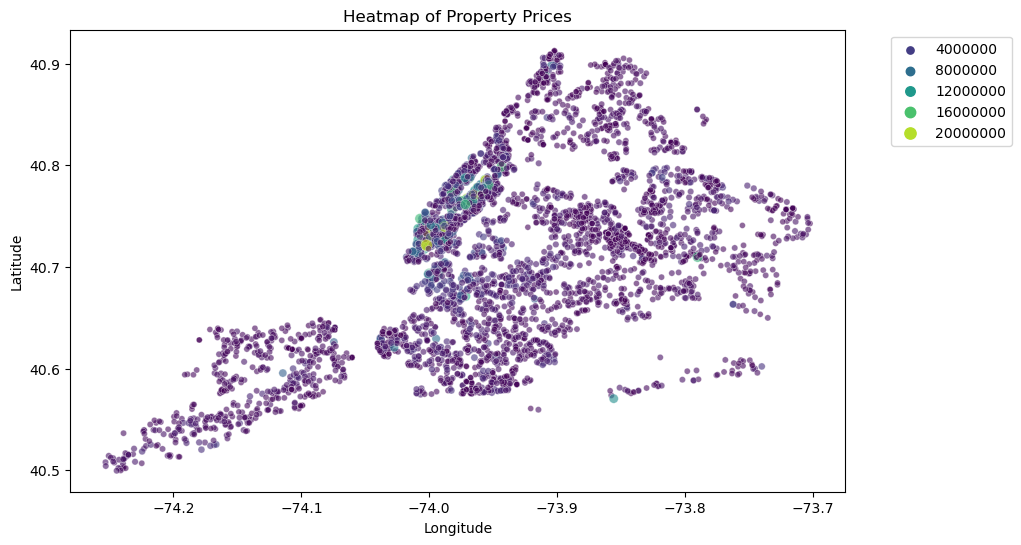

In [95]:
# Visualization Tasks
# Heatmap of property prices
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_cleaned, x='LONGITUDE', y='LATITUDE', size='PRICE', hue='PRICE', alpha=0.6, palette='viridis')
plt.title("Heatmap of Property Prices")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

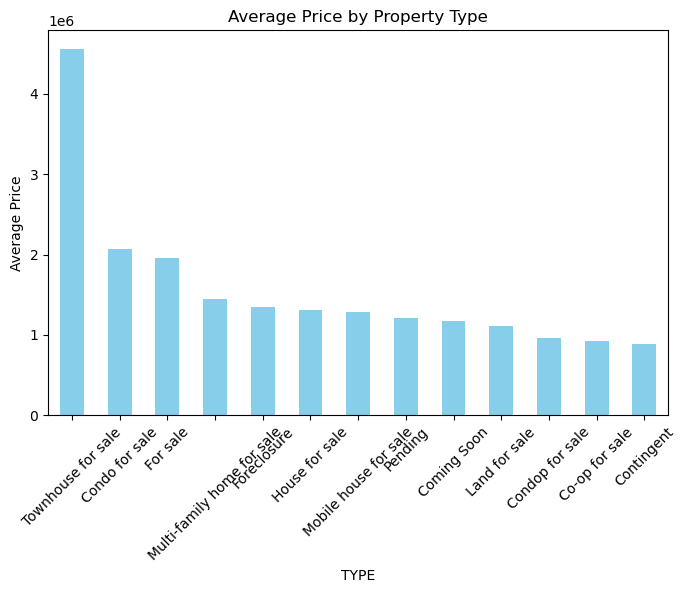

In [96]:
# Average price by property type
plt.figure(figsize=(8, 5))
price_by_type.plot(kind='bar', color='skyblue')
plt.title("Average Price by Property Type")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.show()

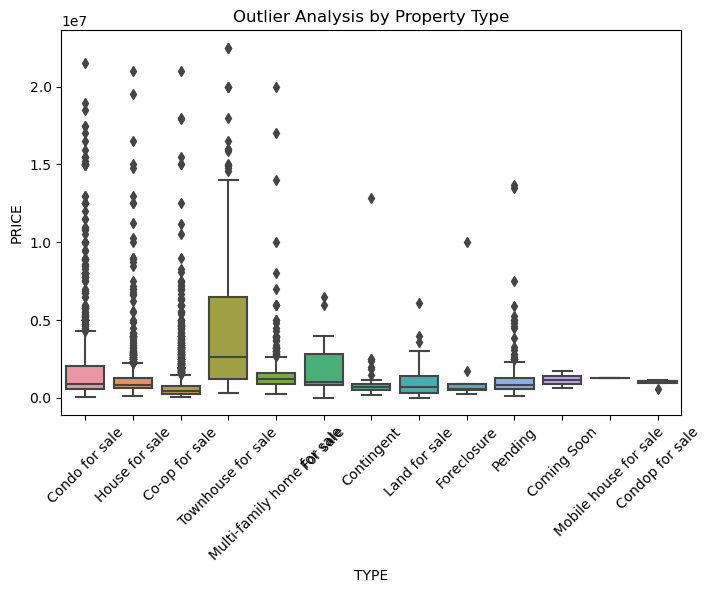

In [97]:
# --- Outlier Analysis ---
# Boxplot for outliers by property type
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_cleaned, x='TYPE', y='PRICE')
plt.title("Outlier Analysis by Property Type")
plt.xticks(rotation=45)
plt.show()

In [98]:
# --- Recommendations ---
# Affordable neighborhoods for investment
investment_opportunities = price_by_locality.tail(10)
print("\nTop 10 affordable neighborhoods for investment:")
print(investment_opportunities)


Top 10 affordable neighborhoods for investment:
LOCALITY
New York          1799676.47
Brooklyn          1426166.67
United States     1327848.32
Kings County       850264.98
Flatbush           650000.00
Queens             517333.33
Richmond County    449264.40
Queens County      443988.55
Bronx County       338824.95
The Bronx          306000.00
Name: PRICE, dtype: float64
